# Time Series Forecasting with Prophet - An Introduction

### Handy when assessing how: 

#### - Sales will change over time
#### - How a stock price will fluctuate over time
#### - How the price/cost of an item will change over time
#### - Prepping for what services/goods in the market are worthwhile
#### - How your investments will change over time

In [1]:
pip install prophet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 31.6 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 25.8 MB/s eta 0:00:00

[notice] A new release of pip is available: 24.3.1 -> 25.1.1
[notice] To update, run: /opt/anaconda3/bin/python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.style as style
style.use("ggplot")
import seaborn as sns
from prophet import Prophet
import warnings
warnings.filterwarnings("ignore")

In [4]:
n = 365

In [5]:
dates = pd.date_range(start = "2023-01-01", periods = n, freq = "D")

In [8]:
seasonal_effect = 10 * np.sin(np.linspace(0, 2*np.pi, n))
noise = np.random.normal(0, 5, size = n)
trend = np.linspace(50, 200, n)
holiday_effect = np.random.choice([0,1], size = n, p = [0.9, 0.1])
sales = trend + seasonal_effect + noise + holiday_effect * 30
sales

array([ 61.0357231 ,  46.3453473 ,  90.02194001,  55.10895461,
        49.84511487,  49.12557142,  49.69960592,  84.54425707,
        87.88859743,  57.7256481 ,  62.57999086,  57.13871536,
        56.73924725,  83.71099292,  63.80495189,  66.51494536,
        62.23668651,  59.69179267,  62.95594627,  50.96572753,
        64.94908035,  62.26120801,  60.32732104,  58.51488443,
        69.29607137,  75.11618494,  66.40687577,  70.44720307,
        95.61257658,  67.94899121,  68.64284227,  61.2268673 ,
        66.89403336,  65.80376638,  71.68132724,  64.93995455,
        59.99280061,  74.94493507,  73.25512926, 106.56227089,
        72.43815968,  68.20046624,  79.71584362,  74.9435516 ,
        76.58491054,  74.94813129, 111.88749811,  81.4894686 ,
        76.43781501,  70.34627932,  68.99999736,  77.11412435,
        85.11251272,  83.99483772,  80.36775781,  77.42187742,
        84.59243015,  81.17755657,  80.43932234,  78.45626042,
        88.1465224 ,  78.76055446,  84.39932606,  94.88

In [9]:
df = pd.DataFrame({
    "date":dates,
    "sales":sales,
    "holiday_effect":holiday_effect
})

In [10]:
df.head()

,date,sales,holiday_effect
0,2023-01-01,61.035723,0
1,2023-01-02,46.345347,0
2,2023-01-03,90.021940,1
3,2023-01-04,55.108955,0
4,2023-01-05,49.845115,0


In [14]:
df_prophet = df[["date", "sales"]].rename(columns = {"date":"ds", "sales":"y"})
df_prophet.head(4)

,ds,y
0,2023-01-01,61.035723
1,2023-01-02,46.345347
2,2023-01-03,90.021940
3,2023-01-04,55.108955


In [15]:
model = Prophet()

In [16]:
model.fit(df_prophet)

09:13:00 - cmdstanpy - INFO - Chain [1] start processing
09:13:01 - cmdstanpy - INFO - Chain [1] done processing


In [17]:
future_dates = pd.date_range(start = "2024-01-01", periods = 30, freq = "D")
future_df = pd.DataFrame({"ds":future_dates})

In [18]:
future_df.head(4)

,ds
0,2024-01-01
1,2024-01-02
2,2024-01-03
3,2024-01-04


In [19]:
forecast = model.predict(future_df)
forecast.head(4)

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2024-01-01,201.387109,190.108200,214.861149,201.387109,201.387109,0.881519,0.881519,0.881519,0.881519,0.881519,0.881519,0.0,0.0,0.0,202.268628
1,2024-01-02,201.913854,189.286309,213.346146,201.913854,201.913854,-0.947069,-0.947069,-0.947069,-0.947069,-0.947069,-0.947069,0.0,0.0,0.0,200.966784
2,2024-01-03,202.440599,190.921913,214.971085,202.440599,202.440599,0.583435,0.583435,0.583435,0.583435,0.583435,0.583435,0.0,0.0,0.0,203.024034
3,2024-01-04,202.967344,190.494132,214.794759,202.964319,202.970311,-0.298619,-0.298619,-0.298619,-0.298619,-0.298619,-0.298619,0.0,0.0,0.0,202.668725


In [21]:
forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].head()

,ds,yhat,yhat_lower,yhat_upper
0,2024-01-01,202.268628,190.108200,214.861149
1,2024-01-02,200.966784,189.286309,213.346146
2,2024-01-03,203.024034,190.921913,214.971085
3,2024-01-04,202.668725,190.494132,214.794759
4,2024-01-05,201.178439,188.715116,213.813452


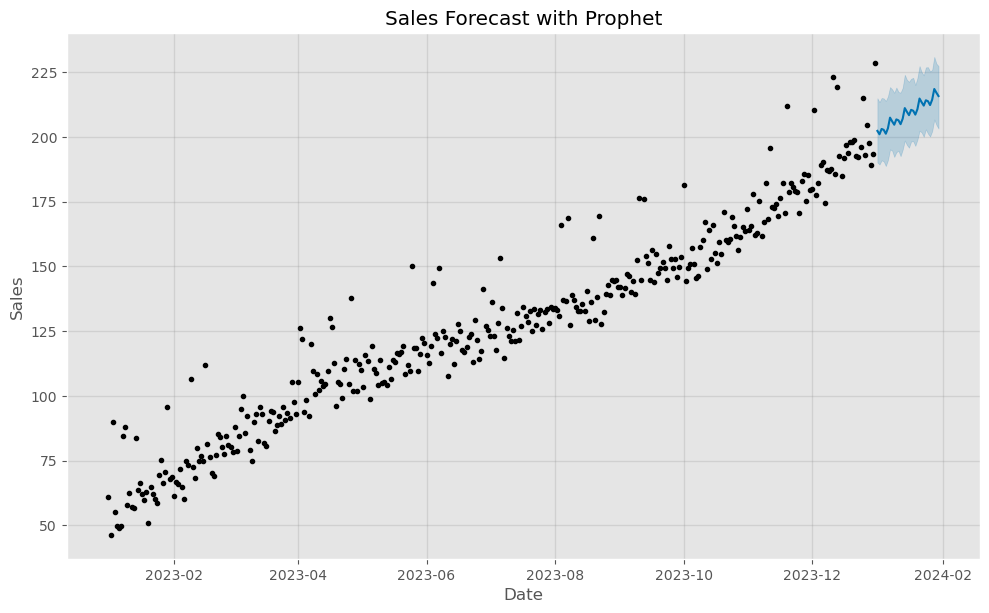

In [23]:
model.plot(forecast)
plt.title("Sales Forecast with Prophet")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

### Alternative with color change option

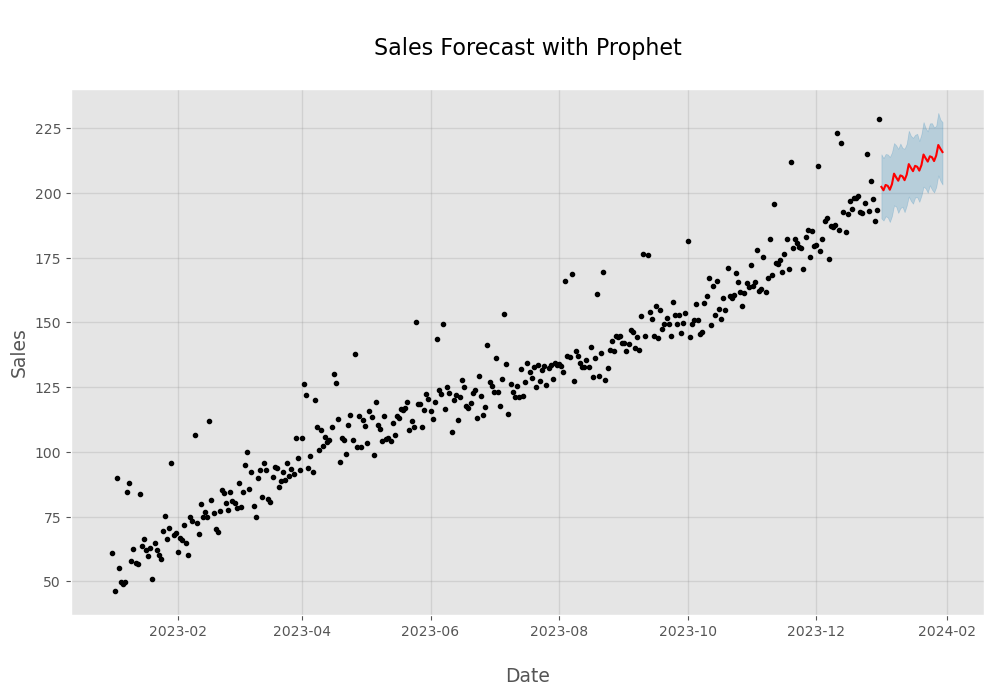

In [29]:
fig = model.plot(forecast)
ax = fig.gca()
ax.get_lines()[1].set_color('red')  

ax.set_title("\nSales Forecast with Prophet\n", fontsize = 16)
ax.set_xlabel("\nDate", fontsize = 13.5)
ax.set_ylabel("Sales", fontsize = 13.5)

plt.show()

In [30]:
import pickle

In [32]:
with open("prophet_model.pkl", "wb") as f:
    pickle.dump(model, f)

with open("prophet_model.pkl", "rb") as f:
    loaded_model = pickle.load(f)
